<h1 style="background-color: #0d2363; color: white; padding: 15px; border-radius: 5px; margin-top: 0;">Student Club EDA </h1>

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b>Introduction & Objectives</b>
<br>The main goal for this EDA is to provide detailed information about the performance of a Hungaryan Student Association <br>
</div>

<h3 style="background-color: #630d32; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">1. Import all the neccessary libraries for the project</h3>

In [9]:
import warnings
from IPython.core.pylabtools import figsize
from pandas.core.methods.selectn import DataFrame
from scipy.cluster.hierarchy import average
from unicodedata import category
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv("Kreditnyilvantartas_renamed_.csv")
df.shape

(151, 24)

In [10]:
def evaluate_status(row):

    col_crit = 'credit_criteria_met'
    col_prof = 'ahodit_dropout'

    val_crit = str(row[col_crit]).lower()
    val_prof = str(row[col_prof]).lower()

    if ('nem teljesítette' in val_crit) or ('kiesett' in val_crit) or \
       ('kiesne' in val_prof) or ('kiesett' in val_prof):
        return 0
    else:
         return 1

df["Final_Retention"] = df.apply(evaluate_status, axis=1)

columns_to_drop = [
    'equity_exemption',
    'unnamed_21',
    'comment',
    'uni_year',
    'org_year'
]

# Drop the columns (with errors='ignore' to prevent KeyError on rerun)
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

credit_columns = [
    'req_elective_courses',
    'free_elective_courses',
    'assembly_participation',
    'demonstrator_activity',
    'teaching_activity',
    'org_leadership_work',
    'presidency_credits',
    'mentor_program',
    'employment_credit',
    'assoc_leadership_credit'
]

for col in credit_columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(",", ".")

    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df["Overall_Credit"] = df[credit_columns].sum(axis=1)

df['gpa'] = df['gpa'].astype(str).str.replace(",", ".")
df['gpa'] = pd.to_numeric(df['gpa'], errors='coerce')

average_grade = df["gpa"].mean()
df['gpa'] = df['gpa'].fillna(average_grade)


df["Van_Versenyeredmeny"] = df['competition_results'].apply(lambda x:
                                                                              0 if str(x).strip() in  ['0', '0.0', 'nan', 'nincs']
                                                                              else 1)


In [11]:
df.iloc[:10]

,id,name,member_org,req_elective_courses,free_elective_courses,assembly_participation,demonstrator_activity,gpa,teaching_activity,competition_results,...,mentor_program,employment_credit,assoc_leadership_credit,total_credit_max30,credit_criteria_met,credit_fail_reason,ahodit_dropout,Final_Retention,Overall_Credit,Van_Versenyeredmeny
0,1.0,Szabó Bence,BTE TE,5.0,8.0,1.0,0.0,3.000000,0.0,0.0,...,3.0,2.0,0.0,27.0,Teljesítve,Teljesítve,NaN,1,24.0,0
1,2.0,Farkas Péter,BVE TE,0.0,0.0,-3.0,0.0,2.376923,0.0,0.0,...,0.0,0.0,0.0,-3.0,Nem teljesítette,Kiesett: Szabadon választható < 4,Kiesne: Szakmai kredit < 9,0,-3.0,0
2,3.0,Molnár Balázs,BVE KL,0.0,0.0,1.0,0.0,2.376923,0.0,0.0,...,0.0,0.0,0.0,1.0,Nem teljesítette,Kiesett: Szabadon választható < 4,Kiesne: Szakmai kredit < 9,0,1.0,0
3,4.0,Szabó Éva,BVE KL,4.0,0.0,1.0,0.0,2.376923,0.0,0.0,...,0.0,0.0,0.0,5.0,Nem teljesítette,Kiesett: Szabadon választható < 4,Kiesne: Szakmai kredit < 9,0,5.0,0
4,5.0,Tóth Nóra,BVE TE,0.0,0.0,1.0,0.0,2.376923,0.0,0.0,...,0.0,0.0,0.0,1.0,Nem teljesítette,Kiesett: Szabadon választható < 4,Kiesne: Szakmai kredit < 9,0,1.0,0
5,6.0,Lakatos Máté,BVE KL,5.0,6.0,1.0,0.0,1.500000,0.0,0.0,...,3.0,2.0,0.0,NaN,Teljesítve,Teljesítve,NaN,1,23.0,0
6,7.0,Nagy Levente,BTE TE,5.0,6.0,1.0,0.0,1.500000,0.0,0.0,...,3.0,2.0,0.0,NaN,Teljesítve,Teljesítve,NaN,1,27.0,0
7,8.0,Kiss Péter,BVE KL,0.0,4.0,1.0,0.0,1.500000,0.0,0.0,...,0.0,2.0,0.0,NaN,Teljesítve,Teljesítve,Kiesne: Szakmai kredit < 9,0,22.0,0
8,9.0,Fekete Dóra,PTE PANE,8.0,6.0,1.0,0.0,2.376923,0.0,0.0,...,3.0,2.0,0.0,26.0,Teljesítve,Teljesítve,NaN,1,26.0,0
9,10.0,Nagy Éva,BTE TE,0.0,4.0,1.0,0.0,1.500000,0.0,0.0,...,3.0,2.0,0.0,NaN,Nem teljesítette,Kiesett: Összes kredit < 15,Kiesne: Szakmai kredit < 9,0,10.0,0


In [12]:
print(df.isna().sum())

id                          0
name                        0
member_org                  0
req_elective_courses        0
free_elective_courses       0
assembly_participation      0
demonstrator_activity       0
gpa                         0
teaching_activity           0
competition_results         0
org_leadership_work         0
presidency_credits          0
mentor_program              0
employment_credit           0
assoc_leadership_credit     0
total_credit_max30         17
credit_criteria_met         8
credit_fail_reason          8
ahodit_dropout             82
Final_Retention             0
Overall_Credit              0
Van_Versenyeredmeny         0
dtype: int64


<h3 style="background-color: #630d32; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Target Variables</h3>

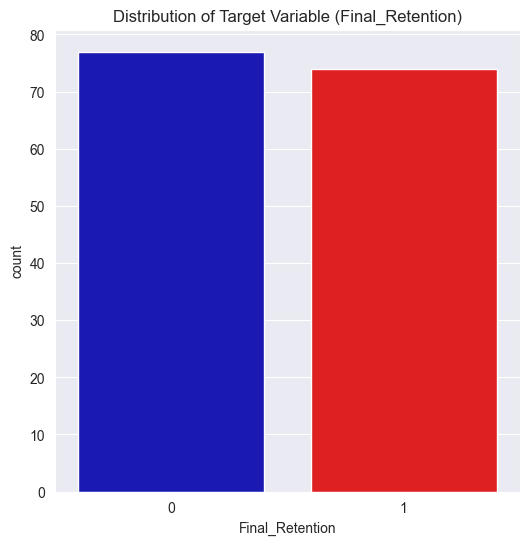

In [13]:
def target_variables(dataframe: pd.DataFrame) -> None:
    binary_palette = ["mediumblue", "red"]
    plt.figure(figsize=(6,6))
    sns.countplot(x=dataframe["Final_Retention"], palette=binary_palette)
    plt.title("Distribution of Target Variable (Final_Retention)")
    plt.show()

target_variables(df)

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b> Under construction</b>
<br> **Under construction** <br>
</div>

<h3 style="background-color: #630d32; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Category Vairables</h3>

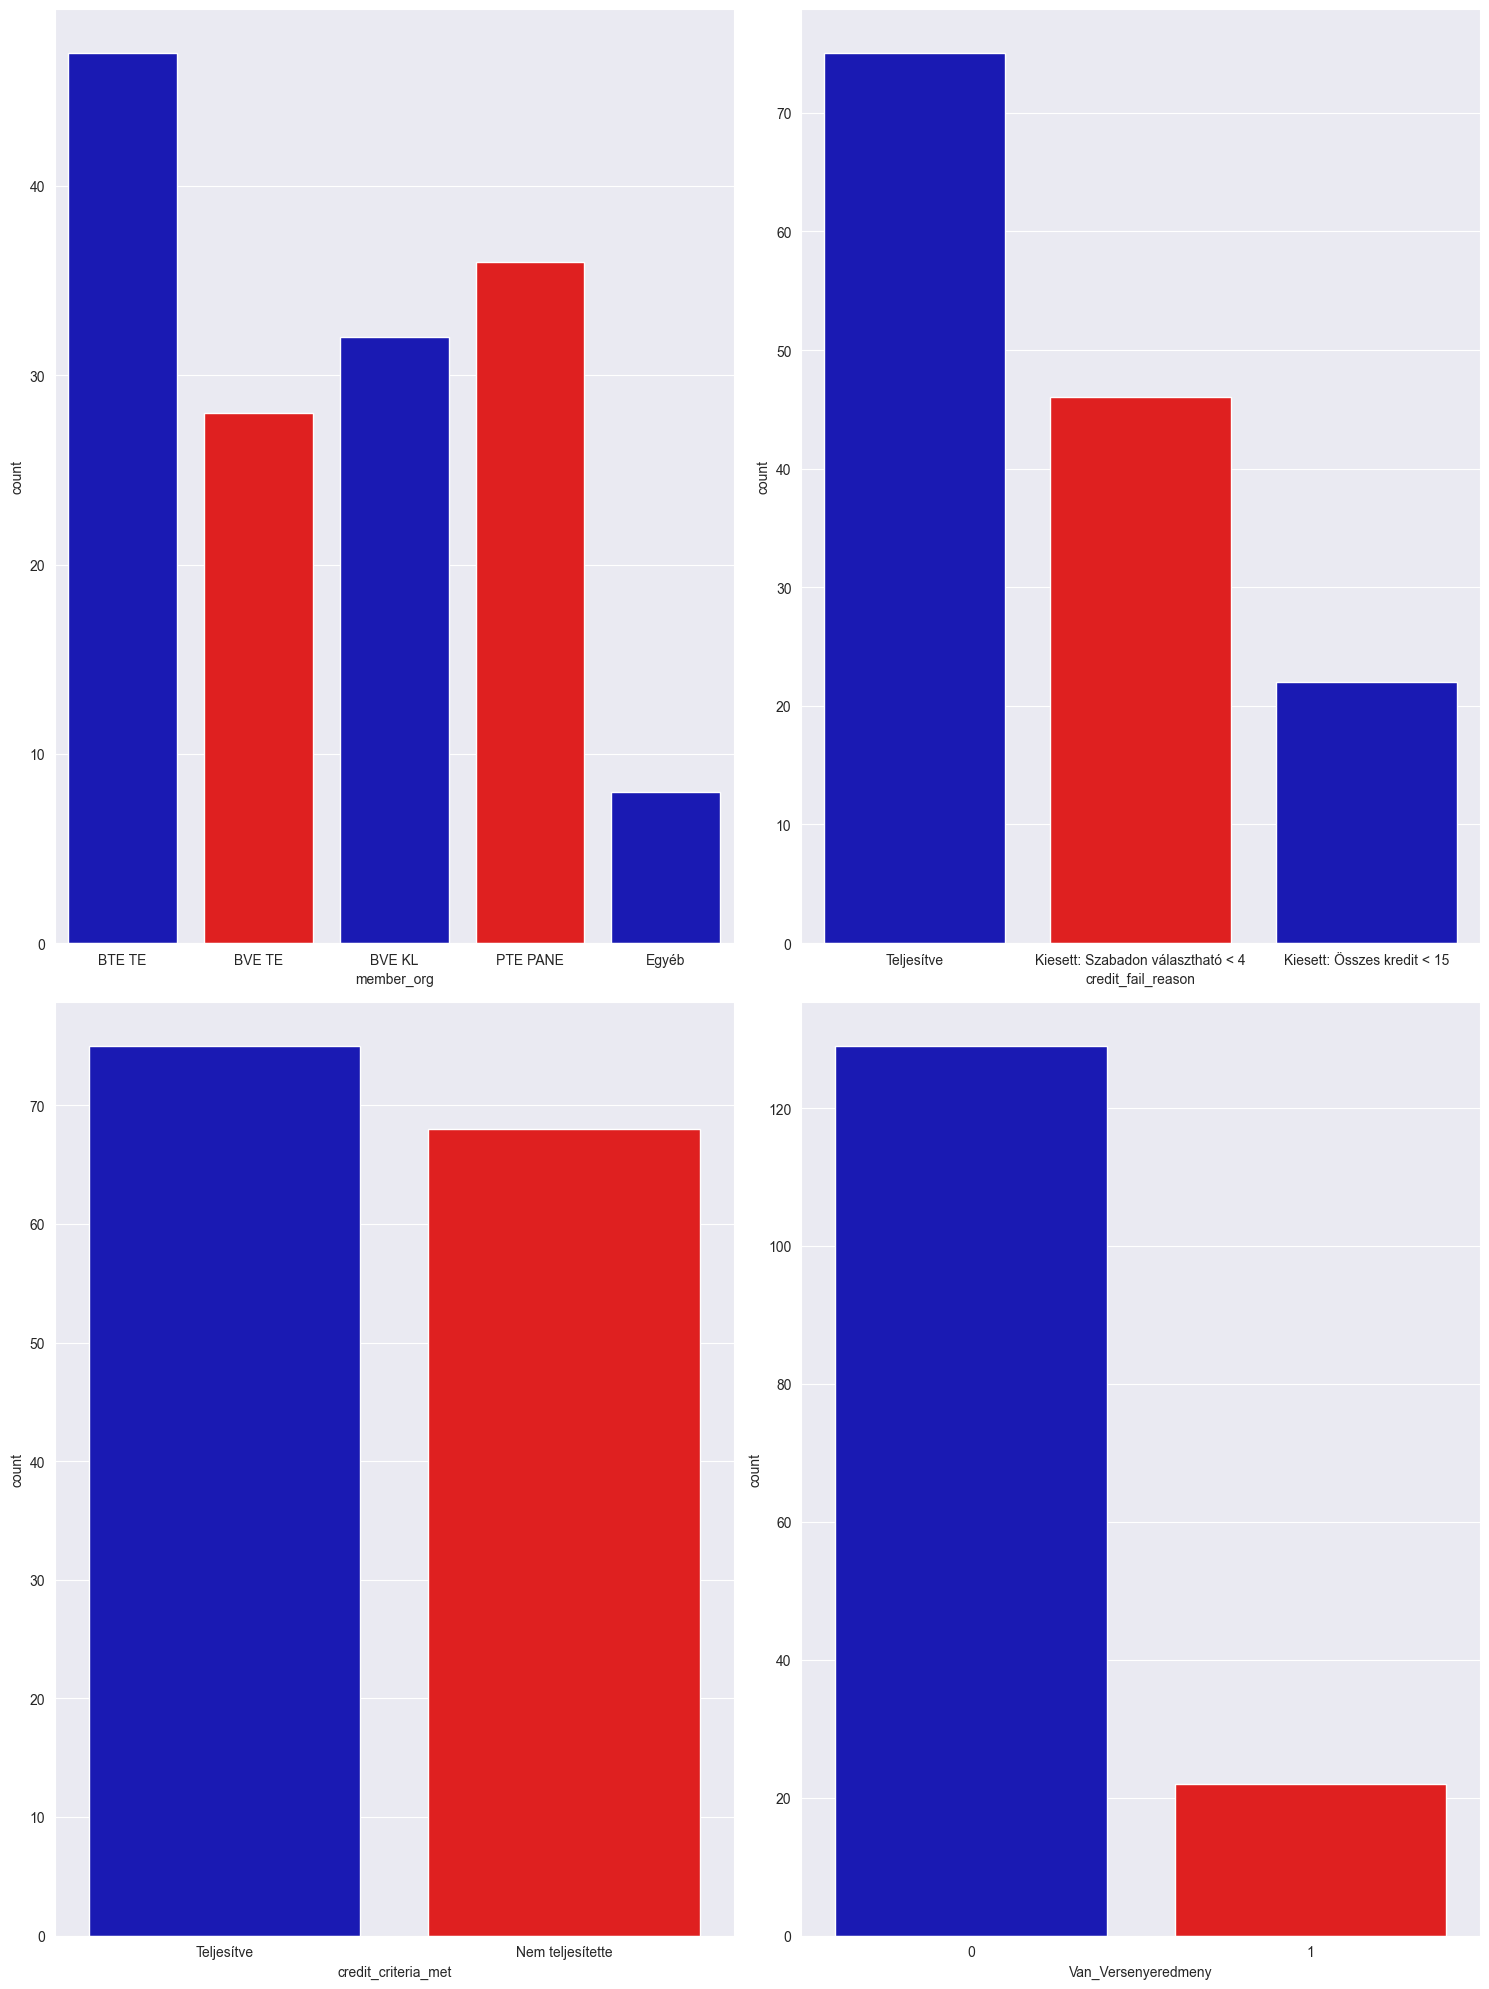

In [14]:
def category_vairables(dataframe: pd.DataFrame) -> None:

    binary_palette = ["mediumblue", "red"]


    categorical_variables = ["member_org", "credit_fail_reason", "credit_criteria_met", "Van_Versenyeredmeny"]


    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15,20))

    for var, subplot in zip(categorical_variables, axes.flatten()):
        sns.countplot(x=var, data=dataframe, ax=subplot, palette=binary_palette)
        for label in subplot.get_xticklabels():
           label.set_rotation(0)


    plt.tight_layout()
    plt.show()

category_vairables(df)

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b> Under construction</b>
<br> **Under construction** <br>
</div>

<h3 style="background-color: #630d32; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Continous Vairables</h3>

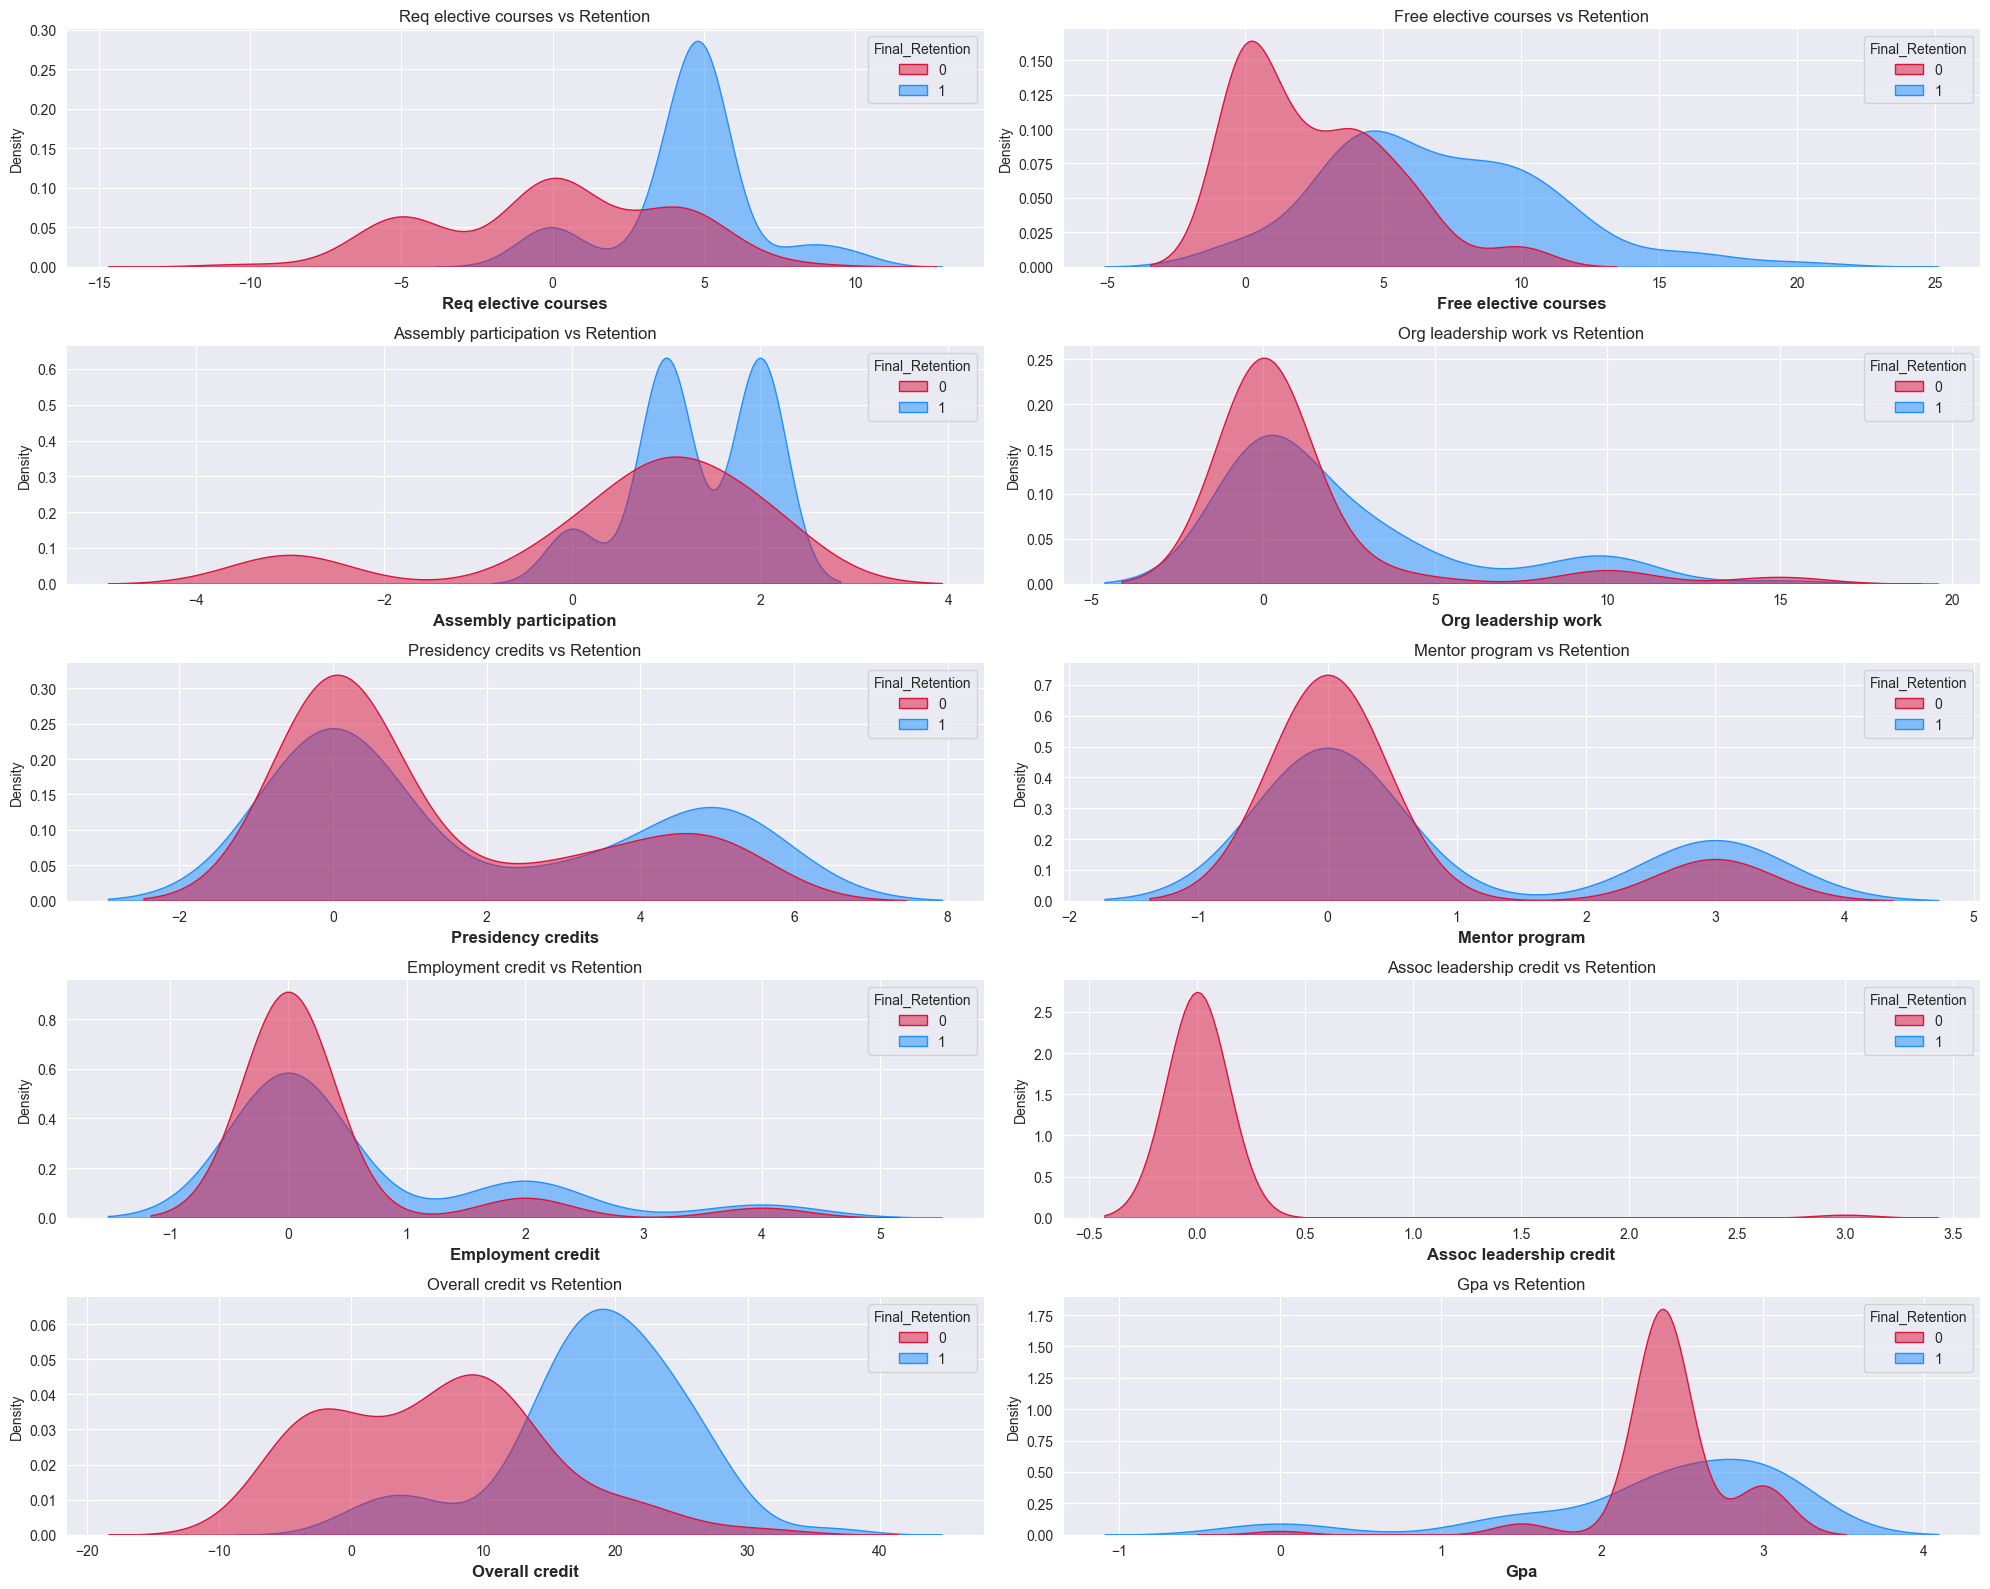

In [17]:
def continuous_variables_histogram(dataframe: pd.DataFrame) -> None:
    continuous_columns = [
        "req_elective_courses", "free_elective_courses", "assembly_participation", "org_leadership_work",
        "presidency_credits", "mentor_program", "employment_credit",
        "assoc_leadership_credit", "Overall_Credit", "gpa"
    ]
    binary_palette = ["crimson", "dodgerblue"]
    fig, axs = plt.subplots(5, 2, figsize=(20, 16))

    for var, subplot in zip(continuous_columns, axs.flatten()):
        sns.kdeplot(data=dataframe, x=var, hue="Final_Retention", fill=True, ax=subplot, palette=binary_palette, alpha=0.5, common_norm=False, warn_singular=False)
        subplot.set_xlabel(var.replace("_", " ").capitalize(), fontsize=12, fontweight='bold')
        subplot.set_title(f"{var.replace('_', ' ').capitalize()} vs Retention")
        sns.despine()

    plt.tight_layout()
    plt.show()


continuous_variables_histogram(df)

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b> Under construction</b>
<br> **Under construction** <br>
</div>

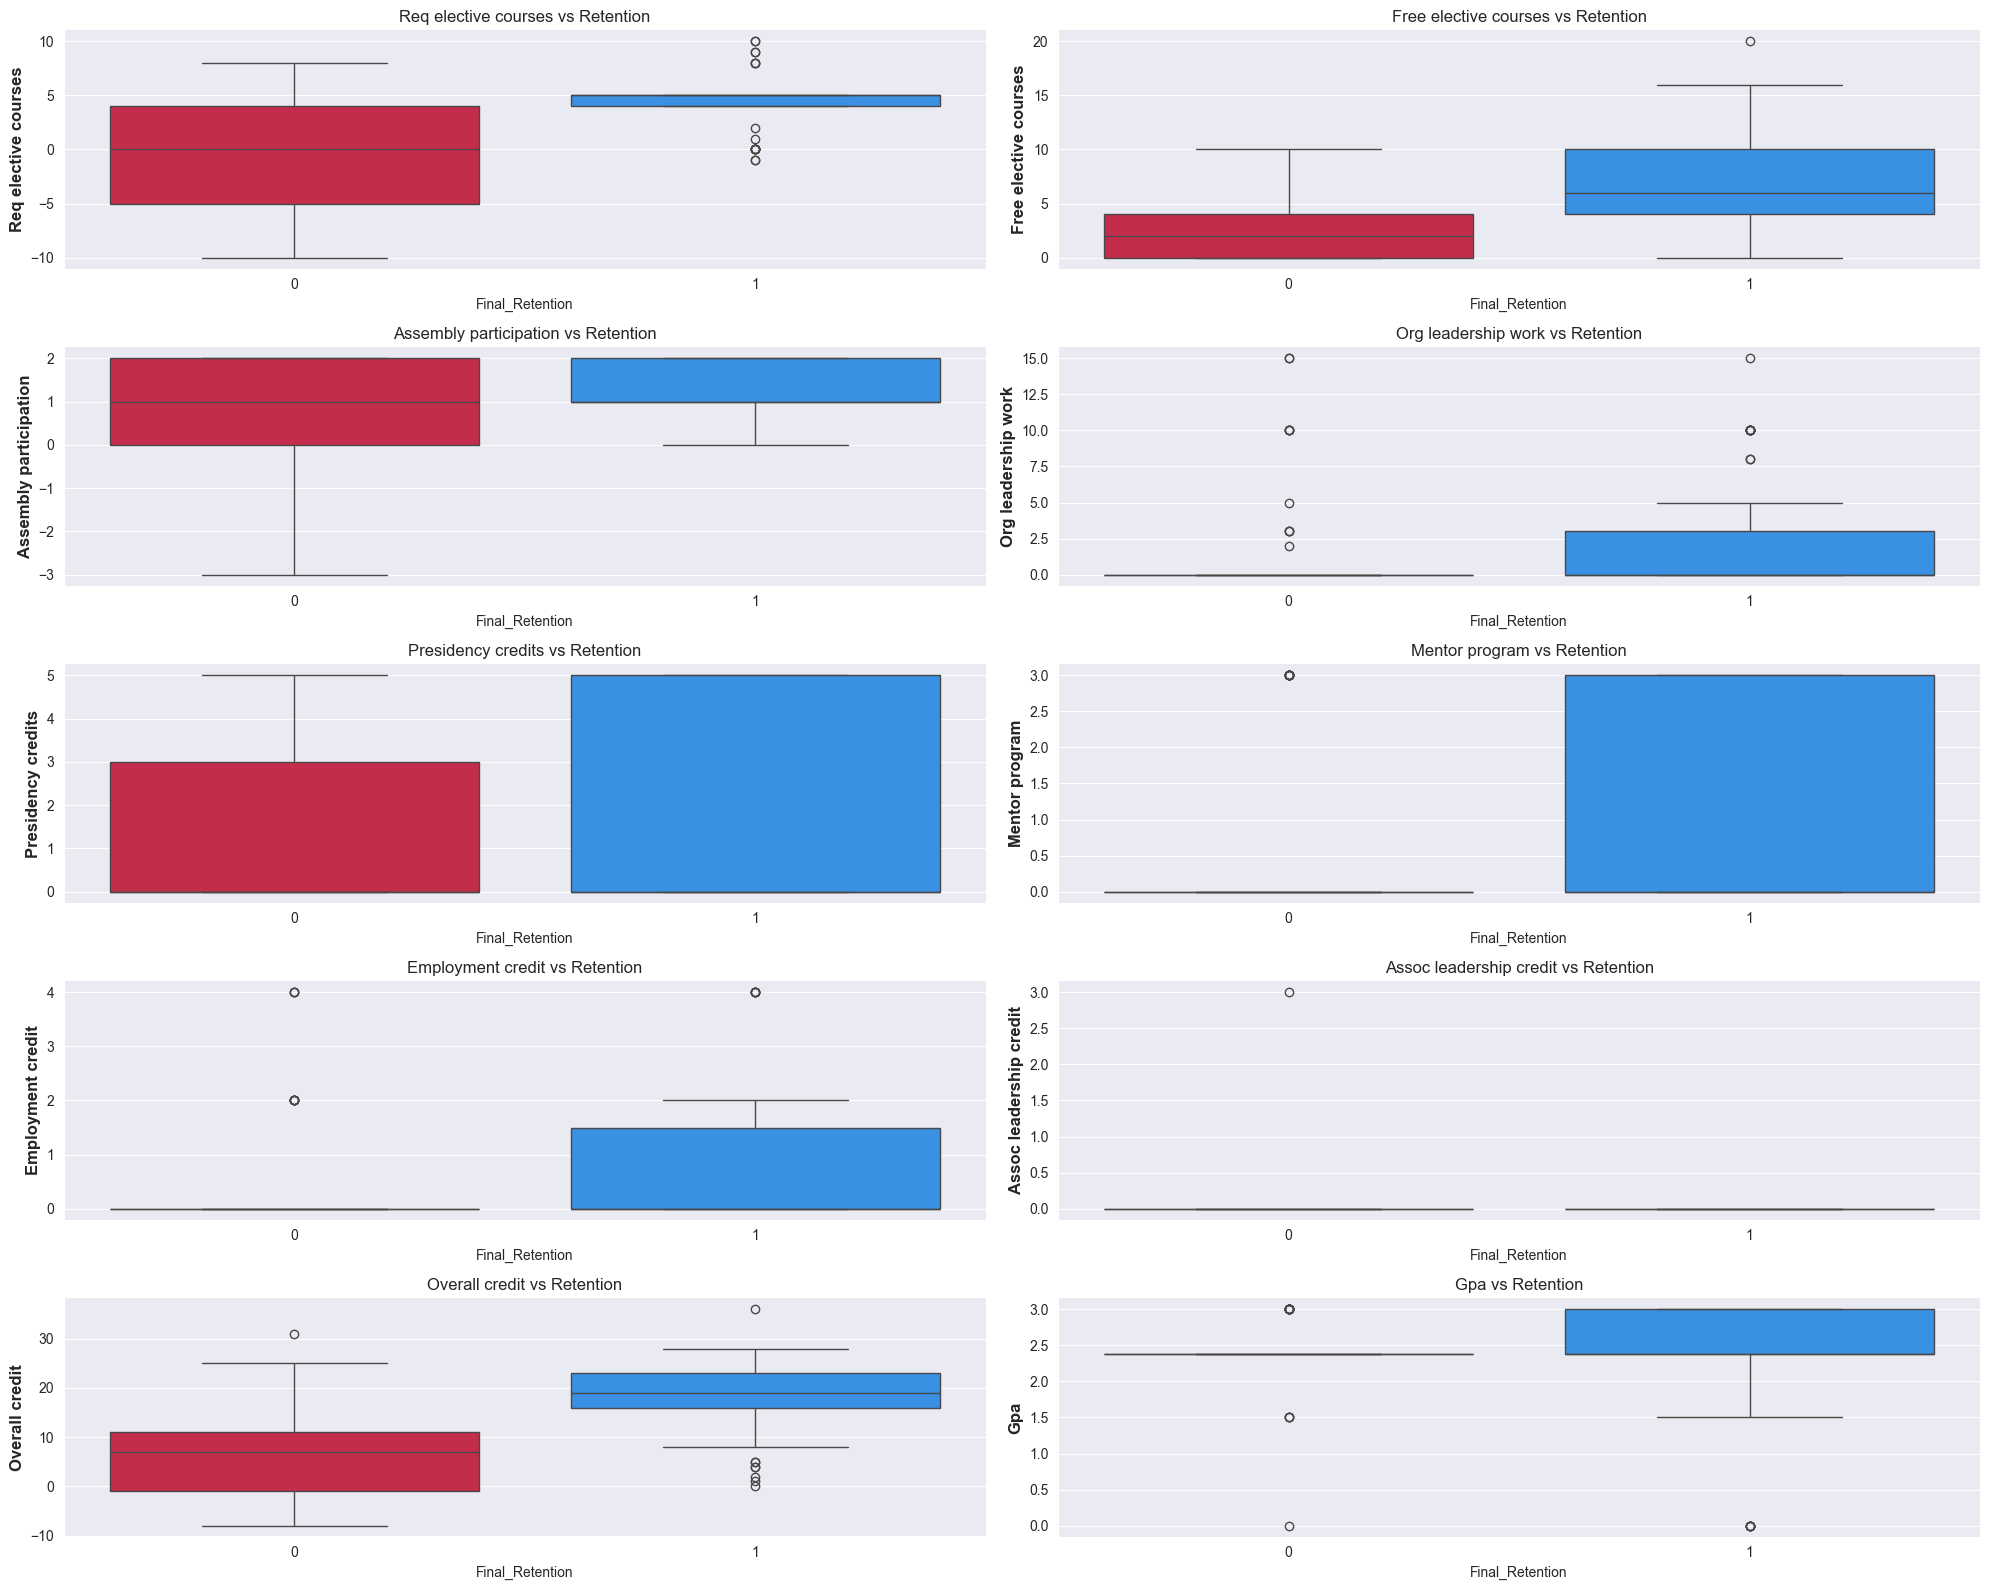

In [21]:
def continuous_variables_boxplot(dataframe: pd.DataFrame) -> None:
    continuous_columns = [
        "req_elective_courses", "free_elective_courses", "assembly_participation", "org_leadership_work",
        "presidency_credits", "mentor_program", "employment_credit",
        "assoc_leadership_credit", "Overall_Credit", "gpa"
    ]

    binary_palette = ["crimson", "dodgerblue"]
    fig, axs = plt.subplots(5, 2, figsize=(20, 16))

    for var, subplot in zip(continuous_columns, axs.flatten()):
        sns.boxplot(data=dataframe, y=var, x="Final_Retention", ax=subplot, palette=binary_palette)
        subplot.set_ylabel(var.replace("_", " ").capitalize(), fontsize=12, fontweight='bold')
        subplot.set_title(f"{var.replace('_', ' ').capitalize()} vs Retention")
        sns.despine()

    plt.tight_layout()
    plt.show()

continuous_variables_boxplot(df)


<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b> Under construction</b>
<br> **Under construction** <br>
</div>